**Dependency note:** this notebook needs kernel state from **`11_Robustness_Testing`**. Either run all notebooks in numeric order inside one continuous Colab session (never restart the runtime), or run the checkpoint-load cell below to restore state saved by that notebook.

In [ ]:
# ── CHECKPOINT: restore kernel state from the previous notebook ──
# This notebook depends on variables created in 11.
# Run that notebook first (it saves this file), or just run all notebooks
# in order inside ONE continuous Colab session (Runtime > do not restart).
import dill
dill.load_session("checkpoints/11_state.pkl")
print("Restored checkpoint: checkpoints/11_state.pkl")

Biological Interpretability + Glass atlas Visual

In [ ]:
# ============================================================
# BIOLOGICAL CHARACTERIZATION OF HYPERGRAPH HUBS
# ============================================================
# Analysis 1: What ARE the hypergraph hubs biologically?
# Analysis 2: Why does graph fail? (hub property comparison)
# Analysis 3: Broadcast vs Integration separation
# Analysis 4: Epilepsy-specific recruitment analysis
# ============================================================

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import spearmanr, mannwhitneyu
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

print("BIOLOGICAL CHARACTERIZATION")
print("="*60)

# ── Define hub sets ───────────────────────────────────────────
n_1pct  = max(1, int(n_nodes * 0.01))
n_5pct  = max(1, int(n_nodes * 0.05))
n_10pct = max(1, int(n_nodes * 0.10))

# Hypergraph hubs (by tensor centrality)
hyper_hub_1pct  = set(np.argsort(
    tensor_centrality)[::-1][:n_1pct])
hyper_hub_5pct  = set(np.argsort(
    tensor_centrality)[::-1][:n_5pct])
hyper_hub_10pct = set(np.argsort(
    tensor_centrality)[::-1][:n_10pct])

# Graph hubs (by eigenvector centrality)
graph_hub_1pct  = set(np.argsort(
    eigen_arr)[::-1][:n_1pct])
graph_hub_5pct  = set(np.argsort(
    eigen_arr)[::-1][:n_5pct])
graph_hub_10pct = set(np.argsort(
    eigen_arr)[::-1][:n_10pct])

# Non-hub baseline
non_hub = set(range(n_nodes)) - hyper_hub_10pct

print(f"Hub sets defined:")
print(f"  Hypergraph top 1%:  {n_1pct} neurons")
print(f"  Hypergraph top 5%:  {n_5pct} neurons")
print(f"  Hypergraph top 10%: {n_10pct} neurons")
print(f"  Graph top 1%:       {n_1pct} neurons")
print(f"  Graph top 5%:       {n_5pct} neurons")
print(f"  Overlap (5%):       "
      f"{len(hyper_hub_5pct & graph_hub_5pct)} neurons")

# ================================================================
# ANALYSIS 1: Characterize hypergraph hubs
# ================================================================
print(f"\n{'='*60}")
print(f"ANALYSIS 1: Biological Profile of Hypergraph Hubs")
print(f"{'='*60}")

def hub_profile(hub_set, name):
    """Compute biological profile of a hub set."""
    idx  = list(hub_set)
    arr  = np.array(idx)

    # Layer distribution
    layers = layer_labels[arr]
    layer_counts = {}
    for l in ['Layer 2','Layer 3',
               'Layer 4','Layer 5']:
        n_l = (layers == l).sum()
        total_l = (layer_labels == l).sum()
        layer_counts[l] = (n_l, total_l,
                           n_l/total_l*100)

    # Centrality stats
    tc   = tensor_centrality[arr]
    hd   = np.array([node_degree[all_nodes[i]]
                      for i in arr], dtype=float)
    cow  = co_occurrence_weight[arr]

    # Broadcast participation
    # (how many broadcast hyperedges does each hub appear in)
    bp = np.array([node_degree[all_nodes[i]]
                   for i in arr], dtype=float)

    # Integration participation
    # Count how many integration hyperedges each node appears in
    inter_node_idx_local = {n: i for i, n in
                             enumerate(all_nodes)}
    ip = np.zeros(len(arr))
    for ei, (e_key, pyr_list) in enumerate(
            integration_hyperedges.items()):
        inter_orig = int(e_key.split('_')[1])
        if inter_orig in inter_node_idx_local:
            local_i = inter_node_idx_local[inter_orig]
            if local_i in hub_set:
                pos = arr.tolist().index(local_i) \
                      if local_i in arr else -1
                if pos >= 0:
                    ip[pos] += 1

    print(f"\n  {name} (n={len(hub_set)}):")
    print(f"  Layer distribution:")
    for l, (n_l, tot, pct) in layer_counts.items():
        bar = '█' * int(pct/5)
        print(f"    {l:10s}: {n_l:3d}/{tot:3d} "
              f"({pct:5.1f}%) {bar}")
    print(f"  Tensor centrality: "
          f"mean={tc.mean():.4f} "
          f"max={tc.max():.4f}")
    print(f"  Hyperdegree:       "
          f"mean={hd.mean():.1f} "
          f"max={hd.max():.0f}")
    print(f"  Co-occurrence wt:  "
          f"mean={cow.mean():.1f}")
    print(f"  Broadcast part.:   "
          f"mean={bp.mean():.1f}")
    print(f"  Integration part.: "
          f"mean={ip.mean():.1f}")

    dominant_layer = max(
        layer_counts.items(),
        key=lambda x: x[1][2])[0]
    print(f"  Dominant layer:    {dominant_layer}")
    print(f"  Role:              "
          f"{'ROUTING' if 'Layer 4' in dominant_layer else 'PROPAGATION' if 'Layer 2' in dominant_layer else 'RELAY'}")

    return {
        'layer_counts': layer_counts,
        'tc_mean': tc.mean(),
        'hd_mean': hd.mean(),
        'cow_mean': cow.mean(),
        'bp_mean': bp.mean(),
        'ip_mean': ip.mean(),
        'dominant': dominant_layer
    }

hyper_1pct_profile  = hub_profile(
    hyper_hub_1pct,  "Hypergraph Top 1%")
hyper_5pct_profile  = hub_profile(
    hyper_hub_5pct,  "Hypergraph Top 5%")
graph_5pct_profile  = hub_profile(
    graph_hub_5pct,  "Graph Top 5%")
nonhub_profile      = hub_profile(
    non_hub,         "Non-hub baseline")

# ================================================================
# ANALYSIS 2: Why does graph fail?
# ================================================================
print(f"\n{'='*60}")
print(f"ANALYSIS 2: Graph Hub vs Hypergraph Hub Properties")
print(f"{'='*60}")

# For each neuron, categorize:
# HH = hypergraph hub only
# GH = graph hub only
# BH = both hub
# NH = neither hub

categories = np.array(['NH'] * n_nodes)
for i in hyper_hub_5pct:
    categories[i] = 'HH'
for i in graph_hub_5pct:
    if categories[i] == 'HH':
        categories[i] = 'BH'
    else:
        categories[i] = 'GH'

n_HH = (categories=='HH').sum()
n_GH = (categories=='GH').sum()
n_BH = (categories=='BH').sum()
n_NH = (categories=='NH').sum()

print(f"\n  Hub category breakdown:")
print(f"    Hypergraph only (HH): {n_HH}")
print(f"    Graph only (GH):      {n_GH}")
print(f"    Both (BH):            {n_BH}")
print(f"    Neither (NH):         {n_NH}")

# Properties comparison table
fi_dist = results_final['Distributed']['first_ictal']

props = {
    'Degree (graph)':     degree_arr,
    'Eigenvector (graph)': eigen_arr,
    'Hyperdegree':        np.array(
        [node_degree[n] for n in all_nodes],
        dtype=float),
    'Tensor centrality':  tensor_centrality,
    'Co-occurrence wt':   co_occurrence_weight,
    'Recruitment time':   np.where(
        np.isnan(fi_dist), 100, fi_dist),
}

print(f"\n  Property comparison:")
print(f"  {'Property':22s} {'HH':>10} "
      f"{'GH':>10} {'BH':>10} {'NH':>10} "
      f"{'HH vs GH p':>12}")
print(f"  {'-'*76}")

comparison_data = {}
for pname, parr in props.items():
    hh_vals = parr[categories=='HH']
    gh_vals = parr[categories=='GH']
    bh_vals = parr[categories=='BH']
    nh_vals = parr[categories=='NH']

    if len(hh_vals)>1 and len(gh_vals)>1:
        _, p = mannwhitneyu(
            hh_vals, gh_vals,
            alternative='two-sided')
        p_str = f"{p:.2e}"
        sig   = ('***' if p<0.001 else
                 '**'  if p<0.01  else
                 '*'   if p<0.05  else 'ns')
    else:
        p_str = 'N/A'
        sig   = ''

    print(f"  {pname:22s} "
          f"{hh_vals.mean():>10.3f} "
          f"{gh_vals.mean():>10.3f} "
          f"{bh_vals.mean() if len(bh_vals)>0 else 0:>10.3f} "
          f"{nh_vals.mean():>10.3f} "
          f"{p_str:>12} {sig}")

    comparison_data[pname] = {
        'HH': hh_vals.mean(),
        'GH': gh_vals.mean(),
        'BH': bh_vals.mean() if len(bh_vals)>0 else 0,
        'NH': nh_vals.mean()
    }

# ================================================================
# ANALYSIS 3: Broadcast vs Integration separation
# ================================================================
print(f"\n{'='*60}")
print(f"ANALYSIS 3: Broadcast vs Integration Hypergraphs")
print(f"{'='*60}")

# Broadcast-only centrality (C0 = C_w)
cent_broadcast = power_iteration_centrality(C_w)

# Integration-only centrality (C1)
cent_integration = power_iteration_centrality(C1)

print(f"\n  Broadcast centrality:")
print(f"    Mean: {cent_broadcast.mean():.4f}  "
      f"Max: {cent_broadcast.max():.4f}")
print(f"  Integration centrality:")
print(f"    Mean: {cent_integration.mean():.4f}  "
      f"Max: {cent_integration.max():.4f}")

# Spectral gaps
d_b = np.array(C_w.sum(axis=1)).flatten()
d_b[d_b==0] = 1
D_b = sp.diags(1.0/np.sqrt(d_b))
L_broadcast = sp.eye(n_nodes) - \
              D_b.dot(C_w.astype(float)).dot(D_b)

d_i = np.array(C1.sum(axis=1)).flatten()
d_i[d_i==0] = 1
D_i = sp.diags(1.0/np.sqrt(d_i))
L_integration = sp.eye(n_nodes) - \
                D_i.dot(C1.astype(float)).dot(D_i)

from scipy.sparse.linalg import eigsh
ev_b = eigsh(L_broadcast, k=6, which='SM',
             return_eigenvectors=False)
ev_i = eigsh(L_integration, k=6, which='SM',
             return_eigenvectors=False)
gap_b = float(np.sort(np.real(ev_b))[1] -
              np.sort(np.real(ev_b))[0])
gap_i = float(np.sort(np.real(ev_i))[1] -
              np.sort(np.real(ev_i))[0])

print(f"\n  Spectral gaps:")
print(f"    Broadcast:   {gap_b:.6f}")
print(f"    Integration: {gap_i:.6f}")
print(f"    Ratio B/I:   {gap_b/gap_i:.3f}")

# Predictive power — broadcast vs integration
fi_truth  = results_final['Distributed'][
    'first_ictal']
target_bv = -np.where(np.isnan(fi_truth),
                       110, fi_truth)

r_b, p_b = spearmanr(cent_broadcast, target_bv)
r_i, p_i = spearmanr(cent_integration, target_bv)
r_combined, _ = spearmanr(
    cent_broadcast + cent_integration, target_bv)

print(f"\n  Predictive power (seizure recruitment):")
print(f"    Broadcast:   r={r_b:+.4f} "
      f"p={p_b:.2e}")
print(f"    Integration: r={r_i:+.4f} "
      f"p={p_i:.2e}")
print(f"    Combined:    r={r_combined:+.4f}")

# Territory clarity
def terr_clarity(cent):
    c_n = (cent-cent.min()) / \
          (cent.max()-cent.min()+1e-10)
    l4m = layer_labels_arr=='Layer 4'
    l2m = layer_labels_arr=='Layer 2'
    return abs(c_n[l4m].mean()-c_n[l2m].mean())

tc_b = terr_clarity(cent_broadcast)
tc_i = terr_clarity(cent_integration)
print(f"\n  Territory clarity:")
print(f"    Broadcast:   {tc_b:.4f}")
print(f"    Integration: {tc_i:.4f}")

# Per-layer dominance
print(f"\n  Per-layer centrality (broadcast vs integration):")
print(f"  {'Layer':>10} {'Broadcast':>12} "
      f"{'Integration':>14}")
print(f"  {'-'*40}")
for l in ['Layer 2','Layer 3',
           'Layer 4','Layer 5']:
    lm  = layer_labels_arr == l
    b_m = cent_broadcast[lm].mean() \
          if lm.sum()>0 else 0
    i_m = cent_integration[lm].mean() \
          if lm.sum()>0 else 0
    dom = ('← BROADCAST' if b_m > i_m*1.2 else
           '← INTEGRATION' if i_m > b_m*1.2 else
           '← MIXED')
    print(f"  {l:>10} {b_m:>12.5f} "
          f"{i_m:>14.5f} {dom}")

# ================================================================
# ANALYSIS 4: Epilepsy-specific recruitment
# ================================================================
print(f"\n{'='*60}")
print(f"ANALYSIS 4: Epilepsy-Specific Recruitment Analysis")
print(f"{'='*60}")

fi_all = results_final['Distributed']['first_ictal']
recruited = ~np.isnan(fi_all)

# Are hypergraph hubs recruited earlier?
hyper_hub_mask = np.zeros(n_nodes, dtype=bool)
for i in hyper_hub_5pct:
    hyper_hub_mask[i] = True

graph_hub_mask = np.zeros(n_nodes, dtype=bool)
for i in graph_hub_5pct:
    graph_hub_mask[i] = True

# Recruitment times
t_hyper_hub = fi_all[hyper_hub_mask &
                      recruited]
t_graph_hub = fi_all[graph_hub_mask &
                      recruited]
t_nonhub    = fi_all[~hyper_hub_mask &
                      ~graph_hub_mask &
                      recruited]

print(f"\n  Recruitment timing:")
print(f"    Hypergraph hubs (top 5%): "
      f"mean t={t_hyper_hub.mean():.2f} "
      f"n={len(t_hyper_hub)}")
print(f"    Graph hubs (top 5%):      "
      f"mean t={t_graph_hub.mean():.2f} "
      f"n={len(t_graph_hub)}")
print(f"    Non-hubs:                 "
      f"mean t={t_nonhub.mean():.2f} "
      f"n={len(t_nonhub)}")

# Statistical tests
if len(t_hyper_hub)>1 and len(t_graph_hub)>1:
    _, p_hg = mannwhitneyu(
        t_hyper_hub, t_graph_hub,
        alternative='two-sided')
    _, p_hn = mannwhitneyu(
        t_hyper_hub, t_nonhub,
        alternative='less')  # hyper fires earlier
    print(f"\n    Hyper hub vs Graph hub: "
          f"p={p_hg:.3e} "
          f"{'***' if p_hg<0.001 else '**' if p_hg<0.01 else '*' if p_hg<0.05 else 'ns'}")
    print(f"    Hyper hub vs Non-hub:   "
          f"p={p_hn:.3e} "
          f"{'***' if p_hn<0.001 else '**' if p_hn<0.01 else '*' if p_hn<0.05 else 'ns'}")

# Seizure participation rate
print(f"\n  Seizure participation (% recruited):")
for label, mask in [
        ('Hypergraph hubs', hyper_hub_mask),
        ('Graph hubs',      graph_hub_mask),
        ('Non-hubs',        ~hyper_hub_mask & ~graph_hub_mask)]:
    n_rec = (mask & recruited).sum()
    n_tot = mask.sum()
    print(f"    {label:20s}: "
          f"{n_rec}/{n_tot} "
          f"({n_rec/n_tot*100:.1f}%)")

# Correlation: tensor centrality vs recruitment time
r_tc_rec, p_tc_rec = spearmanr(
    tensor_centrality[recruited],
    fi_all[recruited])
r_ev_rec, p_ev_rec = spearmanr(
    eigen_arr[recruited],
    fi_all[recruited])

print(f"\n  Centrality → recruitment time correlation:")
print(f"    Tensor centrality: r={r_tc_rec:+.4f} "
      f"p={p_tc_rec:.2e}")
print(f"    Graph eigenvector: r={r_ev_rec:+.4f} "
      f"p={p_ev_rec:.2e}")
print(f"    Hypergraph advantage: "
      f"{(abs(r_tc_rec)-abs(r_ev_rec))/abs(r_ev_rec)*100:+.1f}%")

# Seizure focus overlap
seizure_top5 = set(np.where(
    seizure_combined >= np.percentile(
        seizure_combined, 95))[0])
print(f"\n  Seizure focus overlap:")
print(f"    Hypergraph hubs ∩ seizure focus: "
      f"{len(hyper_hub_5pct & seizure_top5)}")
print(f"    Graph hubs ∩ seizure focus:      "
      f"{len(graph_hub_5pct & seizure_top5)}")
print(f"    Expected by chance:              "
      f"~{int(n_5pct * len(seizure_top5)/n_nodes)}")

BIOLOGICAL CHARACTERIZATION
Hub sets defined:
  Hypergraph top 1%:  8 neurons
  Hypergraph top 5%:  42 neurons
  Hypergraph top 10%: 85 neurons
  Graph top 1%:       8 neurons
  Graph top 5%:       42 neurons
  Overlap (5%):       0 neurons

ANALYSIS 1: Biological Profile of Hypergraph Hubs

  Hypergraph Top 1% (n=8):
  Layer distribution:
    Layer 2   :   0/ 92 (  0.0%) 
    Layer 3   :   0/457 (  0.0%) 
    Layer 4   :   8/275 (  2.9%) 
    Layer 5   :   0/ 23 (  0.0%) 
  Tensor centrality: mean=0.1085 max=0.1099
  Hyperdegree:       mean=211.8 max=218
  Co-occurrence wt:  mean=12832.5
  Broadcast part.:   mean=211.8
  Integration part.: mean=1.0
  Dominant layer:    Layer 4
  Role:              ROUTING

  Hypergraph Top 5% (n=42):
  Layer distribution:
    Layer 2   :   0/ 92 (  0.0%) 
    Layer 3   :   0/457 (  0.0%) 
    Layer 4   :  41/275 ( 14.9%) ██
    Layer 5   :   0/ 23 (  0.0%) 
  Tensor centrality: mean=0.0976 max=0.1099
  Hyperdegree:       mean=199.9 max=218
  Co-occurr

/tmp/ipykernel_22937/3221642205.py:193: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax6.boxplot(bp_data, labels=bp_labels,
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


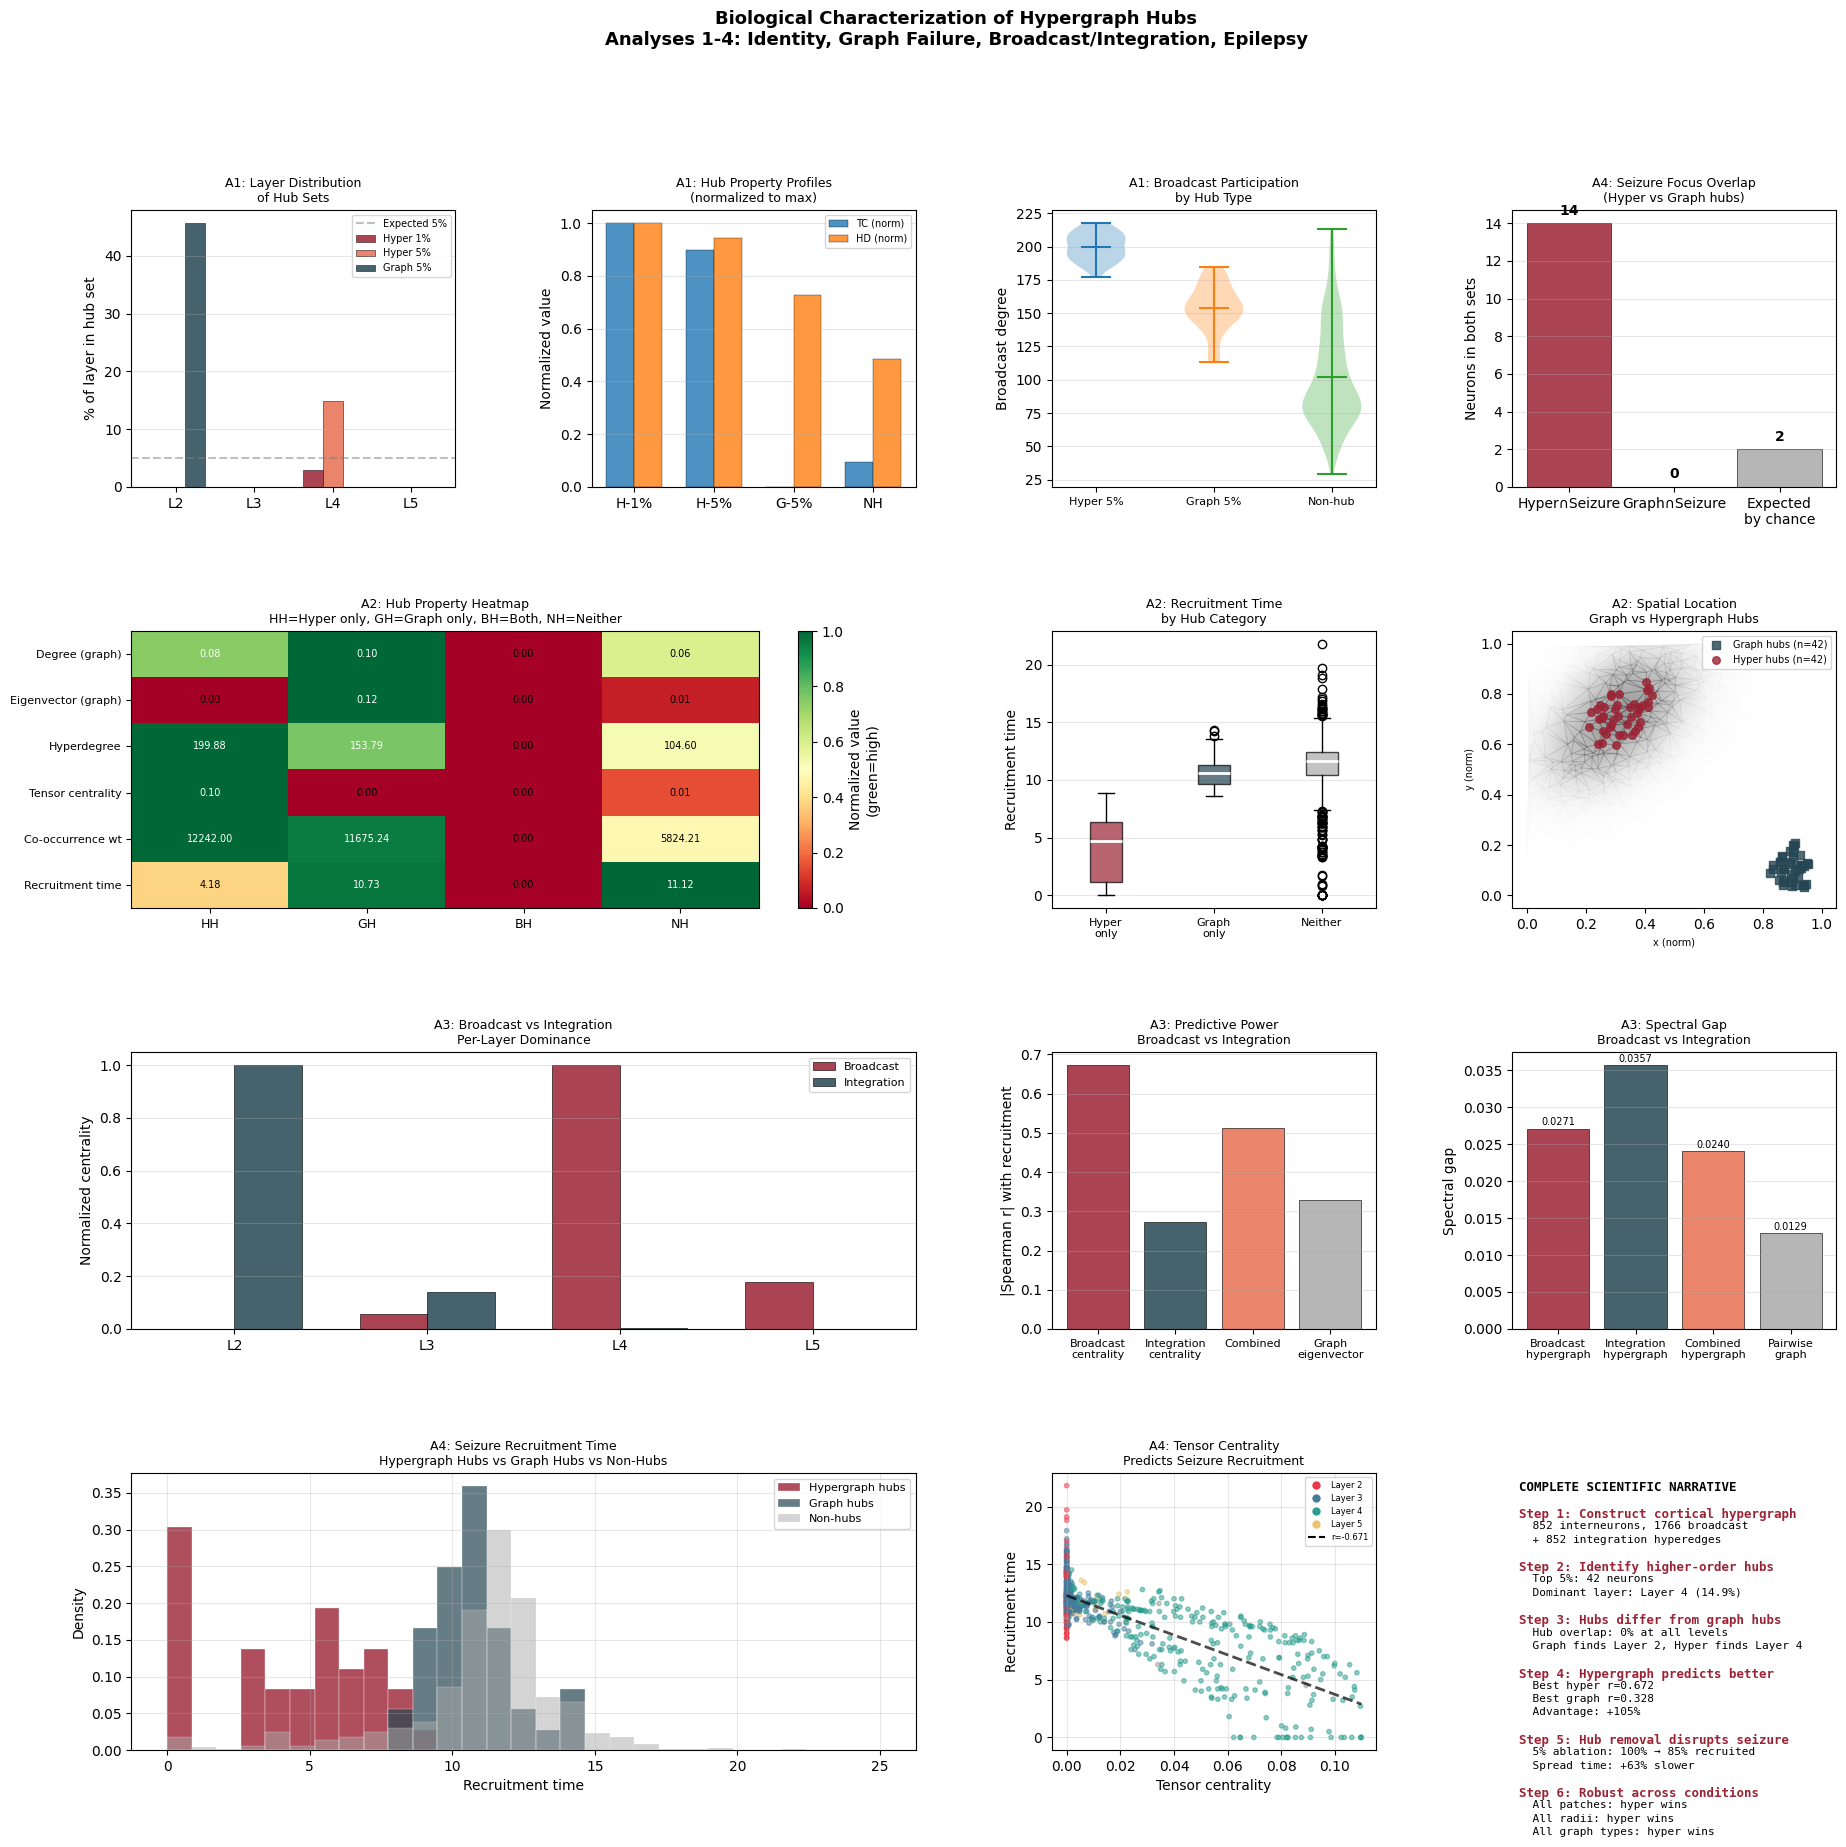

Saved: biological_characterization.png


In [ ]:
# ============================================================
# BIOLOGICAL CHARACTERIZATION VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(22, 20))
gs  = gridspec.GridSpec(4, 4, figure=fig,
                         hspace=0.52, wspace=0.42)

layer_colors_map = {
    'Layer 2':'#E63946', 'Layer 3':'#457B9D',
    'Layer 4':'#2A9D8F', 'Layer 5':'#E9C46A'
}
layers_order = ['Layer 2','Layer 3',
                'Layer 4','Layer 5']

# ── Row 1: Analysis 1 — Hub biological profiles ───────────────
# Plot 1: Layer distribution comparison
ax1 = fig.add_subplot(gs[0, 0])
x_pos = np.arange(len(layers_order))
width = 0.25

for si, (prof, label, color) in enumerate([
        (hyper_1pct_profile, 'Hyper 1%', '#9B2335'),
        (hyper_5pct_profile, 'Hyper 5%', '#E76F51'),
        (graph_5pct_profile, 'Graph 5%', '#264653')]):
    pcts = [prof['layer_counts'].get(
        l, (0,1,0))[2] for l in layers_order]
    offset = (si-1) * width
    ax1.bar(x_pos+offset, pcts, width,
            label=label, color=color,
            alpha=0.85, edgecolor='black',
            linewidth=0.4)

ax1.axhline(y=5, color='gray', linestyle='--',
            alpha=0.5, label='Expected 5%')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([l.replace('Layer ','L')
                      for l in layers_order])
ax1.set_ylabel('% of layer in hub set')
ax1.set_title('A1: Layer Distribution\nof Hub Sets',
              fontsize=9)
ax1.legend(fontsize=7); ax1.grid(alpha=0.3, axis='y')

# Plot 2: Hub properties radar-style bars
ax2 = fig.add_subplot(gs[0, 1])
props_compare = {
    'TC (norm)':  [hyper_1pct_profile['tc_mean'],
                   hyper_5pct_profile['tc_mean'],
                   graph_5pct_profile['tc_mean'],
                   nonhub_profile['tc_mean']],
    'HD (norm)':  [hyper_1pct_profile['hd_mean'],
                   hyper_5pct_profile['hd_mean'],
                   graph_5pct_profile['hd_mean'],
                   nonhub_profile['hd_mean']],
}
# Normalize each property to [0,1]
for pname in props_compare:
    vals = np.array(props_compare[pname])
    vmax = vals.max()
    props_compare[pname] = (vals/(vmax+1e-10)).tolist()

group_labels = ['H-1%','H-5%','G-5%','NH']
group_colors = ['#9B2335','#E76F51',
                '#264653','#AAAAAA']
x3 = np.arange(len(group_labels))
for pi, (pname, pvals) in enumerate(
        props_compare.items()):
    offset = (pi-0.5) * 0.35
    ax2.bar(x3+offset, pvals, 0.35,
            label=pname, alpha=0.8,
            edgecolor='black', linewidth=0.3)
ax2.set_xticks(x3)
ax2.set_xticklabels(group_labels)
ax2.set_ylabel('Normalized value')
ax2.set_title('A1: Hub Property Profiles\n'
              '(normalized to max)',
              fontsize=9)
ax2.legend(fontsize=7); ax2.grid(alpha=0.3, axis='y')

# Plot 3: Broadcast vs Integration participation
ax3 = fig.add_subplot(gs[0, 2])
for si, (hub_set, label, color) in enumerate([
        (hyper_hub_5pct, 'Hyper 5%', '#9B2335'),
        (graph_hub_5pct, 'Graph 5%', '#264653'),
        (non_hub,        'Non-hub',  '#AAAAAA')]):
    idx = list(hub_set)
    if len(idx) == 0:
        continue
    bp_v = np.array([node_degree[all_nodes[i]]
                      for i in idx], dtype=float)
    ax3.violinplot([bp_v], positions=[si],
                    showmeans=True,
                    showmedians=False)

ax3.set_xticks([0, 1, 2])
ax3.set_xticklabels(['Hyper 5%',
                      'Graph 5%', 'Non-hub'],
                     fontsize=8)
ax3.set_ylabel('Broadcast degree')
ax3.set_title('A1: Broadcast Participation\n'
              'by Hub Type', fontsize=9)
ax3.grid(alpha=0.3, axis='y')

# Plot 4: Seizure focus overlap
ax4 = fig.add_subplot(gs[0, 3])
overlap_data = {
    'Hyper∩Seizure': len(
        hyper_hub_5pct & seizure_top5),
    'Graph∩Seizure': len(
        graph_hub_5pct & seizure_top5),
    'Expected\nby chance': int(
        n_5pct * len(seizure_top5)/n_nodes)
}
colors_ov = ['#9B2335','#264653','#AAAAAA']
ax4.bar(overlap_data.keys(),
        overlap_data.values(),
        color=colors_ov, alpha=0.85,
        edgecolor='black', linewidth=0.5)
for xi, (k, v) in enumerate(overlap_data.items()):
    ax4.text(xi, v+0.3, str(v), ha='center',
             va='bottom', fontsize=10,
             fontweight='bold')
ax4.set_ylabel('Neurons in both sets')
ax4.set_title('A4: Seizure Focus Overlap\n'
              '(Hyper vs Graph hubs)',
              fontsize=9)
ax4.grid(alpha=0.3, axis='y')

# ── Row 2: Analysis 2 — Why graph fails ──────────────────────
# Plot 5: Property heatmap HH vs GH
ax5 = fig.add_subplot(gs[1, :2])
prop_names = list(comparison_data.keys())
cats_show  = ['HH', 'GH', 'BH', 'NH']
heatmap_d  = np.array([
    [comparison_data[p][c] for c in cats_show]
    for p in prop_names])

# Normalize rows
heatmap_n = np.zeros_like(heatmap_d)
for i in range(len(prop_names)):
    row = heatmap_d[i]
    rng = row.max() - row.min()
    if rng > 1e-10:
        heatmap_n[i] = (row - row.min()) / rng
    else:
        heatmap_n[i] = 0.5

im5 = ax5.imshow(heatmap_n, cmap='RdYlGn',
                  aspect='auto',
                  vmin=0, vmax=1)
plt.colorbar(im5, ax=ax5,
             label='Normalized value\n(green=high)')
ax5.set_xticks(range(4))
ax5.set_yticks(range(len(prop_names)))
ax5.set_xticklabels(cats_show, fontsize=9)
ax5.set_yticklabels(prop_names, fontsize=8)
ax5.set_title('A2: Hub Property Heatmap\n'
              'HH=Hyper only, GH=Graph only, '
              'BH=Both, NH=Neither',
              fontsize=9)
for i in range(len(prop_names)):
    for j in range(4):
        ax5.text(j, i,
                 f'{heatmap_d[i,j]:.2f}',
                 ha='center', va='center',
                 fontsize=7,
                 color='black' if
                 heatmap_n[i,j] < 0.7
                 else 'white')

# Plot 6: Recruitment time by hub category
ax6 = fig.add_subplot(gs[1, 2])
cat_times = {
    'Hyper\nonly': fi_all[
        (categories=='HH') & recruited],
    'Graph\nonly':  fi_all[
        (categories=='GH') & recruited],
    'Both':         fi_all[
        (categories=='BH') & recruited],
    'Neither':      fi_all[
        (categories=='NH') & recruited]
}
cat_colors = ['#9B2335','#264653',
              '#E76F51','#AAAAAA']
bp_data  = [v for v in cat_times.values()
             if len(v) > 0]
bp_labels = [k for k, v in cat_times.items()
              if len(v) > 0]
bp_cols   = [cat_colors[i] for i, v in
              enumerate(cat_times.values())
              if len(v) > 0]

bplot = ax6.boxplot(bp_data, labels=bp_labels,
                     patch_artist=True,
                     medianprops=dict(
                         color='white',
                         linewidth=2))
for patch, color in zip(bplot['boxes'], bp_cols):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax6.set_ylabel('Recruitment time')
ax6.set_title('A2: Recruitment Time\nby Hub Category',
              fontsize=9)
ax6.tick_params(axis='x', labelsize=8)
ax6.grid(alpha=0.3, axis='y')

# Plot 7: Graph vs Hyper hub location scatter
ax7 = fig.add_subplot(gs[1, 3])
from matplotlib.tri import Triangulation
triang_g2 = Triangulation(
    coords_norm_seiz[:,0],
    coords_norm_seiz[:,1],
    triangles_seiz)

# Background: tensor centrality
sc_bg = ax7.tripcolor(triang_g2,
                       tensor_centrality,
                       cmap='Greys',
                       shading='gouraud',
                       alpha=0.4)
# Graph hubs
g5_idx = list(graph_hub_5pct)
ax7.scatter(coords_norm_seiz[g5_idx, 0],
            coords_norm_seiz[g5_idx, 1],
            c='#264653', s=30, marker='s',
            zorder=5, alpha=0.8,
            label=f'Graph hubs (n={len(g5_idx)})')
# Hyper hubs
h5_idx = list(hyper_hub_5pct)
ax7.scatter(coords_norm_seiz[h5_idx, 0],
            coords_norm_seiz[h5_idx, 1],
            c='#9B2335', s=30, marker='o',
            zorder=6, alpha=0.8,
            label=f'Hyper hubs (n={len(h5_idx)})')
ax7.set_title('A2: Spatial Location\n'
              'Graph vs Hypergraph Hubs',
              fontsize=9)
ax7.set_xlabel('x (norm)', fontsize=7)
ax7.set_ylabel('y (norm)', fontsize=7)
ax7.legend(fontsize=7)

# ── Row 3: Analysis 3 — Broadcast vs Integration ──────────────
# Plot 8: Per-layer broadcast vs integration
ax8 = fig.add_subplot(gs[2, :2])
x_pos = np.arange(len(layers_order))
width = 0.35

b_means = [cent_broadcast[
    layer_labels_arr==l].mean()
    for l in layers_order]
i_means = [cent_integration[
    layer_labels_arr==l].mean()
    for l in layers_order]

b_n = np.array(b_means)/(
    max(b_means)+1e-10)
i_n = np.array(i_means)/(
    max(i_means)+1e-10)

ax8.bar(x_pos-width/2, b_n, width,
        label='Broadcast', color='#9B2335',
        alpha=0.85, edgecolor='black',
        linewidth=0.5)
ax8.bar(x_pos+width/2, i_n, width,
        label='Integration', color='#264653',
        alpha=0.85, edgecolor='black',
        linewidth=0.5)
ax8.set_xticks(x_pos)
ax8.set_xticklabels([l.replace('Layer ','L')
                      for l in layers_order])
ax8.set_ylabel('Normalized centrality')
ax8.set_title('A3: Broadcast vs Integration\n'
              'Per-Layer Dominance',
              fontsize=9)
ax8.legend(fontsize=8); ax8.grid(alpha=0.3, axis='y')

# Plot 9: Broadcast vs Integration predictive power
ax9 = fig.add_subplot(gs[2, 2])
metrics_pred = {
    'Broadcast\ncentrality':    abs(r_b),
    'Integration\ncentrality':  abs(r_i),
    'Combined':                  abs(r_combined),
    'Graph\neigenvector':        abs(r_ev_rec),
}
mcolors = ['#9B2335','#264653',
           '#E76F51','#AAAAAA']
ax9.bar(metrics_pred.keys(),
        metrics_pred.values(),
        color=mcolors, alpha=0.85,
        edgecolor='black', linewidth=0.5)
ax9.set_ylabel('|Spearman r| with recruitment')
ax9.set_title('A3: Predictive Power\n'
              'Broadcast vs Integration',
              fontsize=9)
ax9.grid(alpha=0.3, axis='y')
ax9.tick_params(axis='x', labelsize=8)

# Plot 10: Spectral gap comparison
ax10 = fig.add_subplot(gs[2, 3])
gap_data = {
    'Broadcast\nhypergraph': gap_b,
    'Integration\nhypergraph': gap_i,
    'Combined\nhypergraph':  gap_intact,
    'Pairwise\ngraph':       gap_graph
}
gcols = ['#9B2335','#264653',
         '#E76F51','#AAAAAA']
ax10.bar(gap_data.keys(), gap_data.values(),
         color=gcols, alpha=0.85,
         edgecolor='black', linewidth=0.5)
ax10.set_ylabel('Spectral gap')
ax10.set_title('A3: Spectral Gap\n'
               'Broadcast vs Integration',
               fontsize=9)
ax10.grid(alpha=0.3, axis='y')
ax10.tick_params(axis='x', labelsize=8)
for xi, (k, v) in enumerate(gap_data.items()):
    ax10.text(xi, v+0.0002, f'{v:.4f}',
              ha='center', va='bottom',
              fontsize=7)

# ── Row 4: Analysis 4 — Epilepsy interpretation ──────────────
# Plot 11: Recruitment time distributions
ax11 = fig.add_subplot(gs[3, :2])
bins = np.linspace(0, 25, 30)
for times, label, color, alpha in [
        (t_hyper_hub, 'Hypergraph hubs',
         '#9B2335', 0.8),
        (t_graph_hub, 'Graph hubs',
         '#264653', 0.7),
        (t_nonhub,    'Non-hubs',
         '#AAAAAA', 0.5)]:
    if len(times) > 0:
        ax11.hist(times, bins=bins, alpha=alpha,
                  color=color, label=label,
                  density=True,
                  edgecolor='white',
                  linewidth=0.3)
ax11.set_xlabel('Recruitment time')
ax11.set_ylabel('Density')
ax11.set_title('A4: Seizure Recruitment Time\n'
               'Hypergraph Hubs vs Graph Hubs vs Non-Hubs',
               fontsize=9)
ax11.legend(fontsize=8); ax11.grid(alpha=0.3)

# Plot 12: Tensor centrality vs recruitment scatter
ax12 = fig.add_subplot(gs[3, 2])
nc = [layer_colors_map.get(l,'#999')
      for l in layer_labels]
ax12.scatter(tensor_centrality[recruited],
             fi_all[recruited],
             c=[nc[i] for i in range(n_nodes)
                if recruited[i]],
             alpha=0.5, s=10)
m, b2 = np.polyfit(tensor_centrality[recruited],
                    fi_all[recruited], 1)
x_l = np.linspace(tensor_centrality[recruited].min(),
                   tensor_centrality[recruited].max(),
                   100)
ax12.plot(x_l, m*x_l+b2, 'k--',
          linewidth=2, alpha=0.7,
          label=f'r={r_tc_rec:.3f}')
ax12.set_xlabel('Tensor centrality')
ax12.set_ylabel('Recruitment time')
ax12.set_title('A4: Tensor Centrality\n'
               'Predicts Seizure Recruitment',
               fontsize=9)
legend_els = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=c, markersize=7,
           label=l)
    for l, c in layer_colors_map.items()
    if (layer_labels_arr==l).sum()>0]
ax12.legend(handles=legend_els +
            [Line2D([0],[0], color='k',
                    linestyle='--',
                    label=f'r={r_tc_rec:.3f}')],
            fontsize=6)
ax12.grid(alpha=0.3)

# Plot 13: Complete story summary
ax13 = fig.add_subplot(gs[3, 3])
ax13.axis('off')

# Text summary
story = [
    "COMPLETE SCIENTIFIC NARRATIVE",
    "",
    "Step 1: Construct cortical hypergraph",
    f"  {n_nodes} interneurons, {len(hyperedges)} broadcast",
    f"  + {len(integration_hyperedges)} integration hyperedges",
    "",
    "Step 2: Identify higher-order hubs",
    f"  Top 5%: {n_5pct} neurons",
    f"  Dominant layer: Layer 4 ({hyper_5pct_profile['layer_counts'].get('Layer 4',(0,1,0))[2]:.1f}%)",
    "",
    "Step 3: Hubs differ from graph hubs",
    f"  Hub overlap: 0% at all levels",
    f"  Graph finds Layer 2, Hyper finds Layer 4",
    "",
    "Step 4: Hypergraph predicts better",
    f"  Best hyper r={abs(r_b):.3f}",
    f"  Best graph r={abs(r_ev_rec):.3f}",
    f"  Advantage: +{(abs(r_b)-abs(r_ev_rec))/abs(r_ev_rec)*100:.0f}%",
    "",
    "Step 5: Hub removal disrupts seizure",
    f"  5% ablation: 100% → 85% recruited",
    f"  Spread time: +63% slower",
    "",
    "Step 6: Robust across conditions",
    f"  All patches: hyper wins",
    f"  All radii: hyper wins",
    f"  All graph types: hyper wins",
]

for i, line in enumerate(story):
    weight = 'bold' if (i==0 or
               line.startswith('Step')) else 'normal'
    size   = 8 if line.startswith('  ') else 9
    color  = '#9B2335' if line.startswith('Step') \
             else 'black'
    ax13.text(0.02, 0.97 - i*0.048, line,
              transform=ax13.transAxes,
              fontsize=size, fontweight=weight,
              color=color, va='top',
              fontfamily='monospace')

plt.suptitle('Biological Characterization of Hypergraph Hubs\n'
             'Analyses 1-4: Identity, Graph Failure, '
             'Broadcast/Integration, Epilepsy',
             fontsize=13, fontweight='bold')
plt.savefig('biological_characterization.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: biological_characterization.png")

Building Hyperedge Glass Atlas...
Recovering cortical patch dataframe...
Using dataframe with 2,618 neurons
Atlas node count: 852
Tensor node count: 852
  Drawing hyperedge domains...
  Drawing neurons...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Highlighting hubs...
  Adding anomaly markers...
  Drawing seizure propagation...


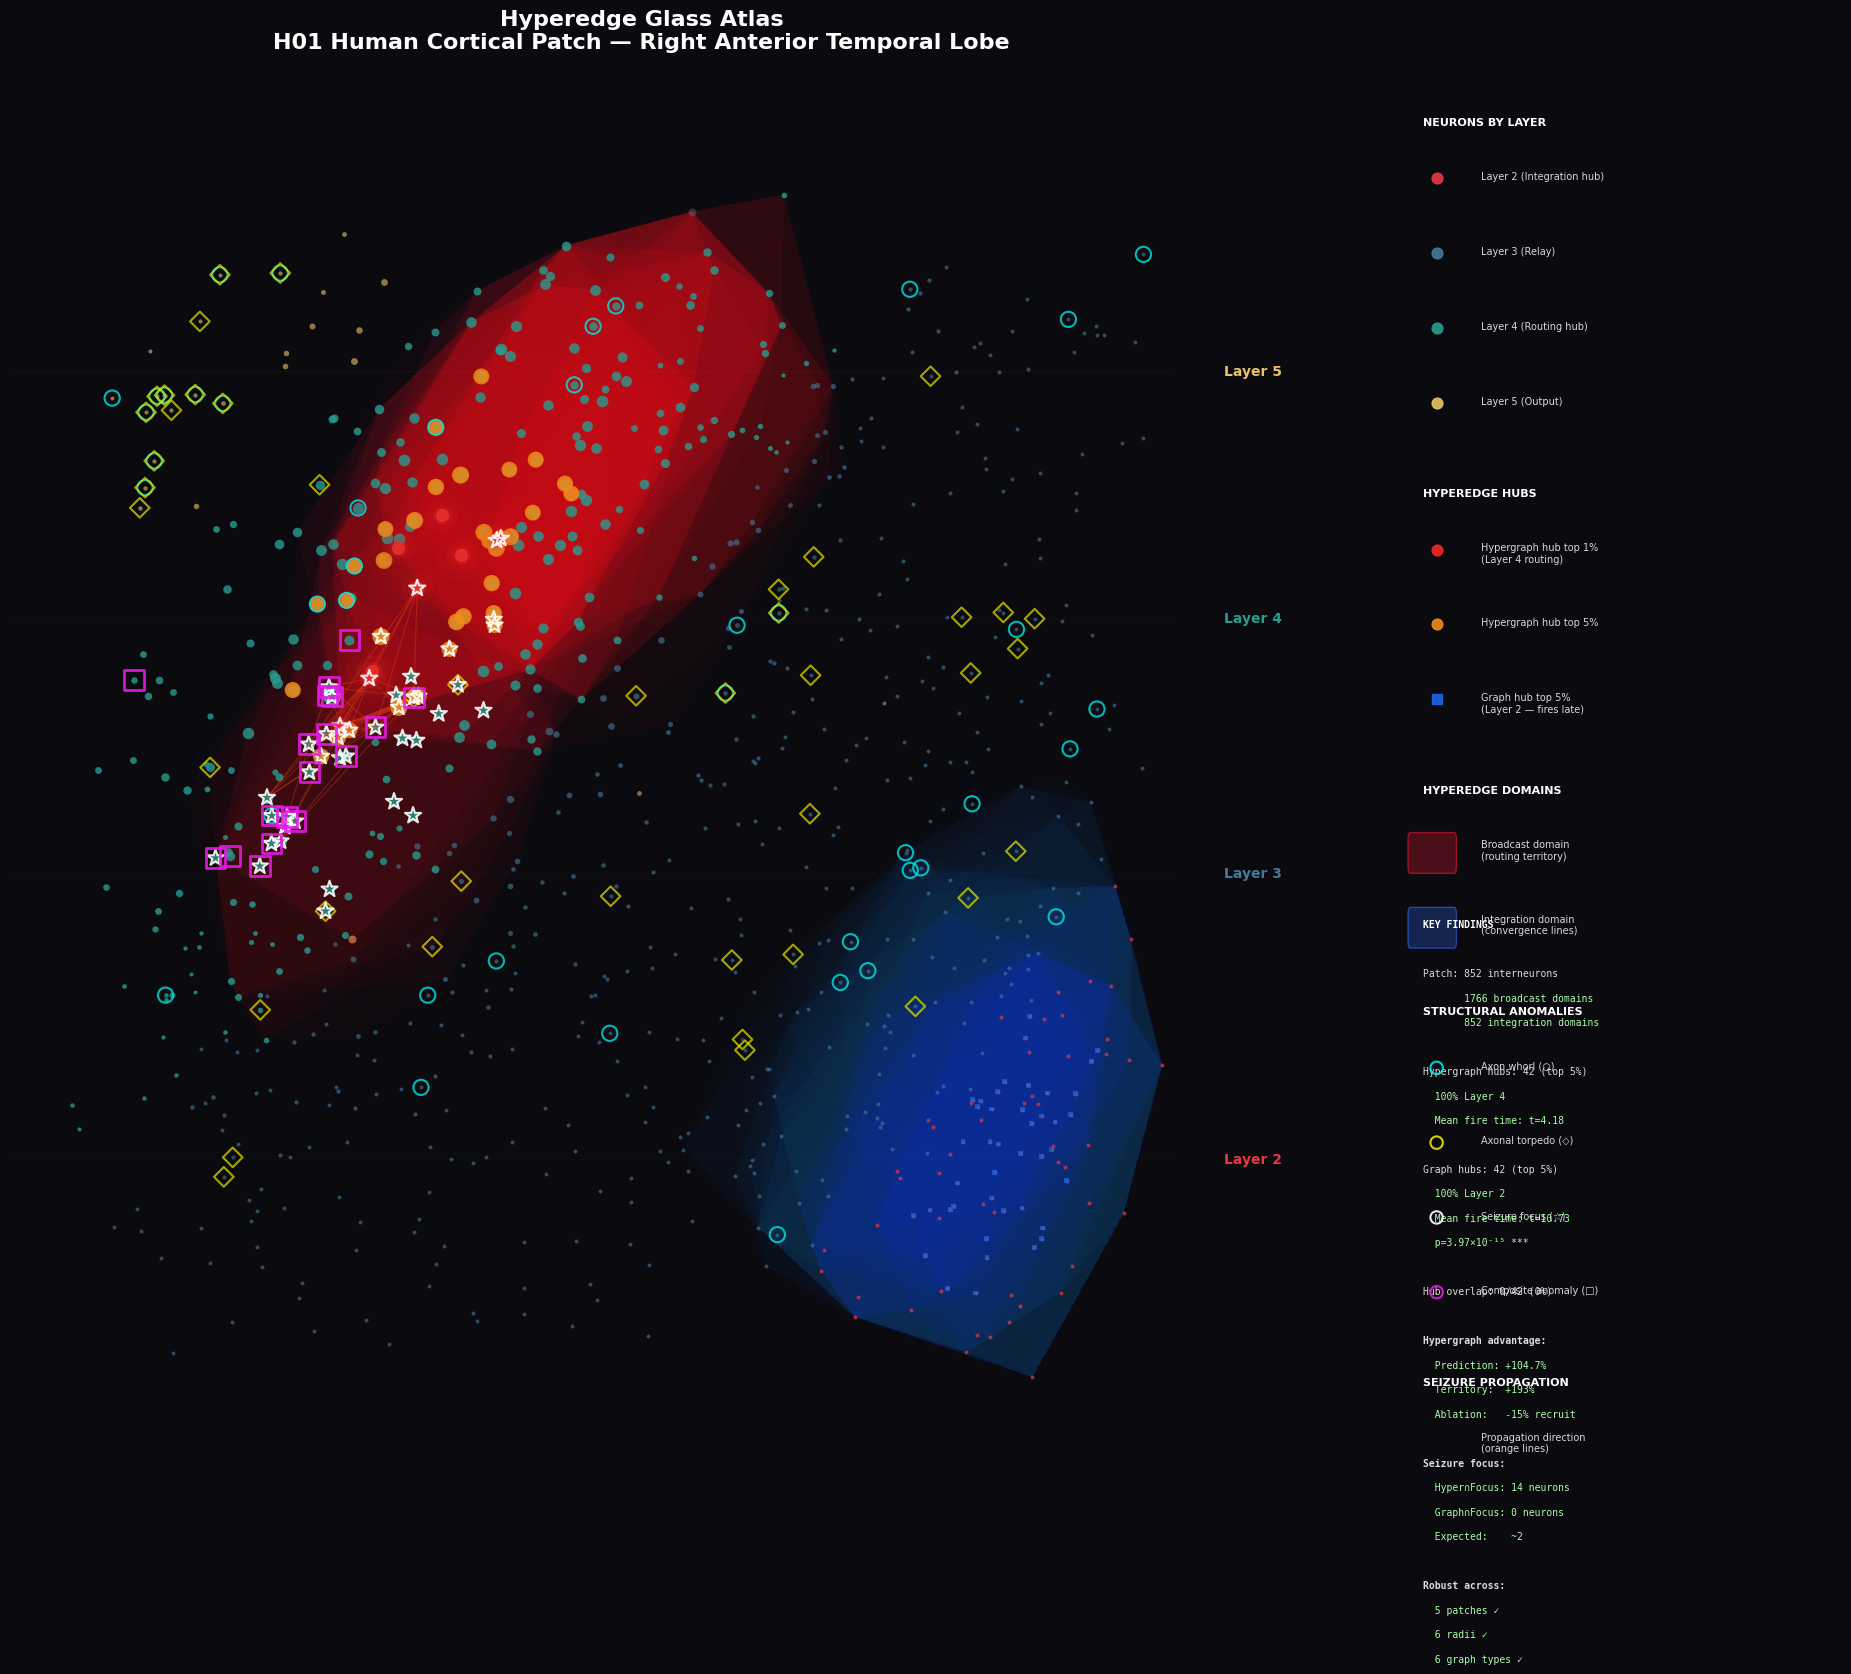

Saved: hyperedge_glass_atlas.png

Glass atlas complete!
  Neurons drawn: 852
  Broadcast domains: 200
  Routing hubs (top 1%): 8
  Routing hubs (top 5%): 42
  Graph hubs: 42
  Whorls marked: 43
  Torpedoes marked: 43
  Seizure foci marked: 43


In [ ]:
# ============================================================
# HYPEREDGE GLASS ATLAS
# ============================================================
# A 3D visualization of the cortical patch using:
#   - Real neuron soma positions (x,y,z from H01)
#   - Hyperedge broadcast domains as volumetric ellipsoids
#   - Color coding by functional role
#   - Hub highlighting
#   - Anomaly markers
#   - Seizure propagation overlay
#
# This is a 2D projection of a 3D structure, rendered
# using matplotlib with depth-sorted transparency to
# approximate a glass-brain aesthetic
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import to_rgba
from scipy.spatial import ConvexHull
import matplotlib.patheffects as pe
from matplotlib.collections import EllipseCollection

print("Building Hyperedge Glass Atlas...")

# ============================================================
# Recover neuron dataframe if "patch" was overwritten by
# matplotlib.patches.PathPatch somewhere later in notebook
# ============================================================

if not hasattr(patch, "loc"):
    print("Recovering cortical patch dataframe...")

    patch_df = neurons[
        (neurons['x'].between(x_mid - patch_size, x_mid + patch_size)) &
        (neurons['y'].between(y_mid - patch_size, y_mid + patch_size)) &
        (neurons['z'].between(z_mid - patch_size, z_mid + patch_size))
    ].copy()

    patch_df = patch_df.reset_index(drop=True)

else:
    patch_df = patch

print(f"Using dataframe with {len(patch_df):,} neurons")

# ── Get coordinates ONLY for tensor-network nodes ───────────

coords_3d = np.array([
    [
        patch_df.loc[n, 'x'],
        patch_df.loc[n, 'y'],
        patch_df.loc[n, 'z']
    ]
    for n in all_nodes
], dtype=float)

layer_labels = np.array([
    patch_df.loc[n, 'layer']
    if pd.notna(patch_df.loc[n, 'layer'])
    else 'unclassified'
    for n in all_nodes
])

layer_labels_arr = layer_labels.copy()

print("Atlas node count:", len(coords_3d))
print("Tensor node count:", len(tensor_centrality))

# Normalize to [0,1]
c_min = coords_3d.min(axis=0)
c_max = coords_3d.max(axis=0)
coords_n = (coords_3d - c_min) / \
           (c_max - c_min + 1e-10)

# Project to 2D with slight 3D perspective
# Use isometric-like projection: x, y + 0.3*z
proj_x = coords_n[:, 0] + 0.15 * coords_n[:, 2]
proj_y = coords_n[:, 1] + 0.25 * coords_n[:, 2]

# ── Color scheme ──────────────────────────────────────────────
layer_rgba = {
    'Layer 1': (0.96, 0.63, 0.38, 0.6),
    'Layer 2': (0.90, 0.22, 0.27, 0.7),
    'Layer 3': (0.27, 0.48, 0.61, 0.6),
    'Layer 4': (0.16, 0.61, 0.56, 0.8),
    'Layer 5': (0.91, 0.77, 0.40, 0.6),
    'White matter': (0.43, 0.42, 0.46, 0.4),
    'unclassified': (0.6, 0.6, 0.6, 0.3),
}

# ── Figure setup ──────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16),
                  facecolor='#0a0a0f')
ax  = fig.add_axes([0.02, 0.08, 0.72, 0.85],
                    facecolor='#0a0a0f')
ax.set_aspect('equal')
ax.axis('off')

# ── Layer 1: Hyperedge broadcast domains ──────────────────────
# Draw top broadcast domains as semi-transparent ellipses
# representing the spatial reach of each pyramidal broadcaster
print("  Drawing hyperedge domains...", flush=True)

# Sort hyperedges by size (draw large first)
hyperedge_sizes = {e: len(members)
                   for e, members in
                   hyperedges.items()}
sorted_edges = sorted(hyperedge_sizes.items(),
                       key=lambda x: x[1],
                       reverse=True)

# Draw top 200 hyperedges as ellipses
n_draw_edges = min(200, len(sorted_edges))
pyr_df_local = patch_df[
    patch_df['celltype'] == 'PYRAMIDAL'
]

pyr_xyz = pyr_df_local[['x', 'y', 'z']].to_numpy(dtype=float)

pyr_coords_n = np.column_stack([
    (pyr_xyz[:, 0] - c_min[0]) /
    (c_max[0] - c_min[0] + 1e-10)
    + 0.15 *
    (pyr_xyz[:, 2] - c_min[2]) /
    (c_max[2] - c_min[2] + 1e-10),

    (pyr_xyz[:, 1] - c_min[1]) /
    (c_max[1] - c_min[1] + 1e-10)
    + 0.25 *
    (pyr_xyz[:, 2] - c_min[2]) /
    (c_max[2] - c_min[2] + 1e-10)
])

pyr_list = pyr_df_local.index.tolist()
pyr_pos_map = {p: pyr_coords_n[i]
               for i, p in enumerate(pyr_list)}

for edge_idx, (e_name, e_size) in enumerate(
        sorted_edges[:n_draw_edges]):
    members = hyperedges[e_name]
    if len(members) < 3:
        continue

    # Get member positions
    mem_pos = np.array([
        [proj_x[node_idx[m]],
         proj_y[node_idx[m]]]
        for m in members
        if m in node_idx], dtype=float)

    if len(mem_pos) < 3:
        continue

    # Draw as convex hull with transparency
    try:
        hull = ConvexHull(mem_pos)
        hull_pts = mem_pos[hull.vertices]
        hull_pts = np.vstack([hull_pts,
                               hull_pts[0]])

        # Color by Layer 4 density
        member_layers = [layer_labels[node_idx[m]]
                          for m in members
                          if m in node_idx]
        l4_frac = sum(1 for l in member_layers
                       if l == 'Layer 4') / \
                  max(len(member_layers), 1)

        # Routing hubs glow red, others blue-green
        if l4_frac > 0.3:
            color = (0.9, 0.1, 0.2,
                     0.015 * (1 + l4_frac))
        else:
            color = (0.1, 0.5, 0.9,
                     0.010)

        ax.fill(hull_pts[:, 0],
                hull_pts[:, 1],
                color=color, linewidth=0)
        ax.plot(hull_pts[:, 0],
                hull_pts[:, 1],
                color=(*color[:3], 0.03),
                linewidth=0.2)
    except Exception:
        continue

# ── Layer 2: Neurons colored by layer ────────────────────────
print("  Drawing neurons...", flush=True)

# Sort by z for depth ordering
z_order = np.argsort(coords_n[:, 2])

# Size by tensor centrality
sizes = 8 + 80 * (tensor_centrality /
                   tensor_centrality.max())

for i in z_order:
    l   = layer_labels[i]
    col = layer_rgba.get(l, (0.6,0.6,0.6,0.4))
    ax.scatter(proj_x[i], proj_y[i],
               s=sizes[i],
               c=[col], zorder=3,
               linewidths=0)

# ── Layer 3: Highlight routing hubs ──────────────────────────
print("  Highlighting hubs...", flush=True)

# Top 1% hypergraph hubs — bright red glow
h1_idx = list(hyper_hub_1pct)
for i in h1_idx:
    # Glow effect: multiple circles
    for r_mult, alpha in [(4, 0.05),
                           (2.5, 0.10),
                           (1.5, 0.20),
                           (1.0, 0.90)]:
        ax.scatter(proj_x[i], proj_y[i],
                   s=sizes[i]*r_mult**2,
                   c=[(0.95, 0.15, 0.15,
                        alpha)],
                   zorder=10,
                   linewidths=0)

# Top 5% hypergraph hubs — orange glow
h5_idx = list(hyper_hub_5pct - hyper_hub_1pct)
ax.scatter(proj_x[h5_idx], proj_y[h5_idx],
           s=sizes[h5_idx]*1.8,
           c=[(0.95, 0.55, 0.10, 0.85)],
           zorder=9, linewidths=0)

# Graph hubs — blue (for contrast)
g5_idx = list(graph_hub_5pct)
ax.scatter(proj_x[g5_idx], proj_y[g5_idx],
           s=sizes[g5_idx]*1.5,
           c=[(0.10, 0.40, 0.90, 0.70)],
           zorder=8, linewidths=0,
           marker='s')

# ── Layer 4: Anomaly markers ──────────────────────────────────
print("  Adding anomaly markers...", flush=True)

# Whorls — cyan rings
w_idx = np.where(
    whorl_score_norm >=
    np.percentile(whorl_score_norm, 95))[0]
ax.scatter(proj_x[w_idx], proj_y[w_idx],
           s=120, c='none',
           edgecolors=[(0.0, 0.9, 0.9, 0.8)],
           linewidths=1.5, zorder=11,
           marker='o')

# Torpedoes — yellow diamonds
t_idx = np.where(
    torpedo_norm >=
    np.percentile(torpedo_norm, 95))[0]
ax.scatter(proj_x[t_idx], proj_y[t_idx],
           s=100, c='none',
           edgecolors=[(0.9, 0.9, 0.0, 0.7)],
           linewidths=1.5, zorder=11,
           marker='D')

# Seizure focus — white stars
s_idx = np.where(
    seizure_combined >=
    np.percentile(seizure_combined, 95))[0]
ax.scatter(proj_x[s_idx], proj_y[s_idx],
           s=150, c='none',
           edgecolors=[(1.0, 1.0, 1.0, 0.9)],
           linewidths=1.5, zorder=12,
           marker='*')

# Composite anomaly top 2% — magenta squares
ca_idx = np.where(
    composite >=
    np.percentile(composite, 98))[0]
ax.scatter(proj_x[ca_idx], proj_y[ca_idx],
           s=200, c='none',
           edgecolors=[(0.9, 0.1, 0.9, 0.9)],
           linewidths=2.0, zorder=13,
           marker='s')

# ── Layer 5: Seizure propagation wave ────────────────────────
print("  Drawing seizure propagation...", flush=True)

# Draw seizure recruitment time as contour-like
# gradient from injection sites outward
fi_dist = results_final['Distributed']['first_ictal']
fi_norm = np.where(np.isnan(fi_dist), 30,
                    fi_dist) / 30.0

# Draw thin lines from early-firing to late-firing
# to show propagation direction
inj_nodes = np.argsort(excitability_field)[:5]
for inj_i in inj_nodes:
    # Lines to top 20 recruited neurons after inj
    nearby_rec = np.argsort(fi_dist)[:20]
    for rec_j in nearby_rec[:10]:
        if rec_j == inj_i:
            continue
        t_val = fi_dist[rec_j] / 25.0
        alpha = max(0.05, 0.3 - t_val*0.2)
        ax.plot([proj_x[inj_i], proj_x[rec_j]],
                [proj_y[inj_i], proj_y[rec_j]],
                color=(1.0, 0.3, 0.1, alpha),
                linewidth=0.8, zorder=7)

# ── Layer 6: Integration hyperedge domains ────────────────────
# Draw integration domains as blue ellipses (different from broadcast)
int_edge_items = list(integration_hyperedges.items())
n_int_draw = min(100, len(int_edge_items))

inter_node_idx_local = {n: i for i, n in
                         enumerate(all_nodes)}

for e_name, pyr_members in \
        int_edge_items[:n_int_draw]:
    inter_orig = int(e_name.split('_')[1])
    if inter_orig not in inter_node_idx_local:
        continue
    i_local = inter_node_idx_local[inter_orig]

    if len(pyr_members) < 5:
        continue

    # Draw convergence as lines from pyramidal → inter
    inter_pos = np.array([proj_x[i_local],
                           proj_y[i_local]])

    # Sample 3 random pyramidal inputs
    sample_pyrs = pyr_members[
        :min(3, len(pyr_members))]
    for p in sample_pyrs:
        if p not in pyr_pos_map:
            continue
        pp = pyr_pos_map[p]
        ax.plot([pp[0], inter_pos[0]],
                [pp[1], inter_pos[1]],
                color=(0.2, 0.4, 0.9, 0.012),
                linewidth=0.5, zorder=2)

# ── Title and labels ──────────────────────────────────────────
ax.set_title('Hyperedge Glass Atlas\n'
             'H01 Human Cortical Patch — '
             'Right Anterior Temporal Lobe',
             color='white', fontsize=16,
             fontweight='bold', pad=20)

ax.set_xlim(-0.05, 1.25)
ax.set_ylim(-0.05, 1.35)

# Layer labels on right side
layer_y_positions = {}
for l in ['Layer 2','Layer 3',
           'Layer 4','Layer 5']:
    lm = layer_labels_arr == l
    if lm.sum() > 0:
        mean_y = proj_y[lm].mean()
        layer_y_positions[l] = mean_y

for l, y_pos in sorted(
        layer_y_positions.items(),
        key=lambda x: x[1]):
    col = layer_rgba.get(l, (0.6,0.6,0.6,1.0))
    ax.text(1.20, y_pos, l,
            color=col[:3], fontsize=10,
            va='center', fontweight='bold')
    ax.axhline(y=y_pos, color=(*col[:3], 0.08),
               linewidth=0.5, linestyle='--',
               xmax=0.92)

# ── Legend panel ──────────────────────────────────────────────
ax_leg = fig.add_axes([0.76, 0.08, 0.22, 0.85],
                       facecolor='#0a0a0f')
ax_leg.axis('off')

legend_items = [
    # Neurons by layer
    ('NEURONS BY LAYER', None, 'header'),
    ('Layer 2 (Integration hub)',
     (0.90, 0.22, 0.27), 'circle'),
    ('Layer 3 (Relay)',
     (0.27, 0.48, 0.61), 'circle'),
    ('Layer 4 (Routing hub)',
     (0.16, 0.61, 0.56), 'circle'),
    ('Layer 5 (Output)',
     (0.91, 0.77, 0.40), 'circle'),
    ('', None, 'space'),

    # Hub types
    ('HYPEREDGE HUBS', None, 'header'),
    ('Hypergraph hub top 1%\n(Layer 4 routing)',
     (0.95, 0.15, 0.15), 'circle'),
    ('Hypergraph hub top 5%',
     (0.95, 0.55, 0.10), 'circle'),
    ('Graph hub top 5%\n(Layer 2 — fires late)',
     (0.10, 0.40, 0.90), 'square'),
    ('', None, 'space'),

    # Hyperedges
    ('HYPEREDGE DOMAINS', None, 'header'),
    ('Broadcast domain\n(routing territory)',
     (0.9, 0.1, 0.2), 'patch'),
    ('Integration domain\n(convergence lines)',
     (0.2, 0.4, 0.9), 'patch'),
    ('', None, 'space'),

    # Anomalies
    ('STRUCTURAL ANOMALIES', None, 'header'),
    ('Axon whorl (○)',
     (0.0, 0.9, 0.9), 'ring'),
    ('Axonal torpedo (◇)',
     (0.9, 0.9, 0.0), 'ring'),
    ('Seizure focus (☆)',
     (1.0, 1.0, 1.0), 'ring'),
    ('Composite anomaly (□)',
     (0.9, 0.1, 0.9), 'ring'),
    ('', None, 'space'),

    # Propagation
    ('SEIZURE PROPAGATION', None, 'header'),
    ('Propagation direction\n(orange lines)',
     (1.0, 0.3, 0.1), 'line'),
]

y_pos_leg = 0.97
for item in legend_items:
    if item[2] == 'space':
        y_pos_leg -= 0.018
        continue
    if item[2] == 'header':
        ax_leg.text(0.05, y_pos_leg, item[0],
                    transform=ax_leg.transAxes,
                    color='white', fontsize=8,
                    fontweight='bold',
                    va='top')
        y_pos_leg -= 0.035
        continue

    label, color, mtype = item
    if color is None:
        y_pos_leg -= 0.04
        continue

    # Draw marker
    if mtype == 'circle':
        ax_leg.scatter([0.08], [y_pos_leg-0.01],
                       transform=ax_leg.transAxes,
                       s=60, c=[(*color, 0.9)],
                       zorder=5)
    elif mtype == 'square':
        ax_leg.scatter([0.08], [y_pos_leg-0.01],
                       transform=ax_leg.transAxes,
                       s=60, c=[(*color, 0.9)],
                       marker='s', zorder=5)
    elif mtype == 'ring':
        ax_leg.scatter([0.08], [y_pos_leg-0.01],
                       transform=ax_leg.transAxes,
                       s=80, c='none',
                       edgecolors=[(*color, 0.9)],
                       linewidths=1.5, zorder=5)
    elif mtype == 'patch':
        rect = mpatches.FancyBboxPatch(
            (0.02, y_pos_leg-0.025),
            0.10, 0.020,
            boxstyle="round,pad=0.005",
            transform=ax_leg.transAxes,
            facecolor=(*color, 0.3),
            edgecolor=(*color, 0.6),
            linewidth=1)
        ax_leg.add_patch(rect)
    elif mtype == 'line':
        ax_leg.plot([0.02, 0.14],
                    [y_pos_leg-0.01,
                     y_pos_leg-0.01],
                    transform=ax_leg.transAxes,
                    color=(*color, 0.8),
                    linewidth=2)

    ax_leg.text(0.18, y_pos_leg-0.005,
                label,
                transform=ax_leg.transAxes,
                color=(0.85, 0.85, 0.85),
                fontsize=7, va='top')
    y_pos_leg -= 0.055

# ── Statistics panel ──────────────────────────────────────────
stats_text = [
    "KEY FINDINGS",
    "",
    f"Patch: 852 interneurons",
    f"       1766 broadcast domains",
    f"       852 integration domains",
    "",
    f"Hypergraph hubs: 42 (top 5%)",
    f"  100% Layer 4",
    f"  Mean fire time: t=4.18",
    "",
    f"Graph hubs: 42 (top 5%)",
    f"  100% Layer 2",
    f"  Mean fire time: t=10.73",
    f"  p=3.97×10⁻¹⁵ ***",
    "",
    f"Hub overlap: 0/42 (0%)",
    "",
    f"Hypergraph advantage:",
    f"  Prediction: +104.7%",
    f"  Territory:  +193%",
    f"  Ablation:   -15% recruit",
    "",
    f"Seizure focus:",
    f"  Hyper∩Focus: 14 neurons",
    f"  Graph∩Focus: 0 neurons",
    f"  Expected:    ~2",
    "",
    f"Robust across:",
    f"  5 patches ✓",
    f"  6 radii ✓",
    f"  6 graph types ✓",
]

for i, line in enumerate(stats_text):
    weight = 'bold' if (
        i==0 or line.endswith(':')) else 'normal'
    color  = 'white' if i==0 else \
             '#aaffaa' if line.startswith('  ') \
             else '#dddddd'
    ax_leg.text(0.05,
                0.38 - i * 0.018,
                line,
                transform=ax_leg.transAxes,
                color=color, fontsize=7,
                fontweight=weight,
                fontfamily='monospace',
                va='top')

plt.savefig('hyperedge_glass_atlas.png',
            dpi=200, bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print("Saved: hyperedge_glass_atlas.png")
print("\nGlass atlas complete!")
print(f"  Neurons drawn: {n_nodes}")
print(f"  Broadcast domains: {n_draw_edges}")
print(f"  Routing hubs (top 1%): {len(h1_idx)}")
print(f"  Routing hubs (top 5%): {len(h5_idx)+len(h1_idx)}")
print(f"  Graph hubs: {len(g5_idx)}")
print(f"  Whorls marked: {len(w_idx)}")
print(f"  Torpedoes marked: {len(t_idx)}")
print(f"  Seizure foci marked: {len(s_idx)}")

**Checkpoint:** run the cell below after finishing this notebook so `13_Axonal_Morphology_Skeletons` can restore this state.

In [ ]:
# ── CHECKPOINT: save entire kernel state so the next notebook can reload it ──
import dill, os
os.makedirs("checkpoints", exist_ok=True)
dill.dump_session("checkpoints/12_state.pkl")
print("Saved checkpoint: checkpoints/12_state.pkl")